<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/exoplanet_HR8799.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exoplanet HR8799**

[HR 8799 ](https://de.m.wikipedia.org/wiki/HR_8799) is a 30 million-year-old main-sequence star located 133.3 light-years (40.9 parsecs) away from Earth in the constellation of Pegasus

Paper: [Direct emission spectroscopy of exoplanets with the medium
resolution imaging spectrometer on board JWST MIRI](https://www.aanda.org/articles/aa/pdf/2022/02/aa41663-21.pdf)

In [ ]:
# Lightkurve library installed, which is specifically designed to work with Kepler and TESS data.
!pip install lightkurve -q
import lightkurve as lk

In [ ]:
from astropy import units as u
import lightkurve as lk
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [ ]:
datalist = lk.search_targetpixelfile("HR8799")
datalist

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 56,2022,SPOC,20,245368902,0.0
1,TESS Sector 56,2022,SPOC,120,245368902,0.0
2,TESS Sector 56,2022,TESS-SPOC,200,245368902,0.0


In [ ]:
tes = datalist[(datalist.author == "SPOC") & (datalist.exptime == 120*u.second)][0].download()

<Axes: title={'center': 'Target ID: 245368902, Cadence: 1150418'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

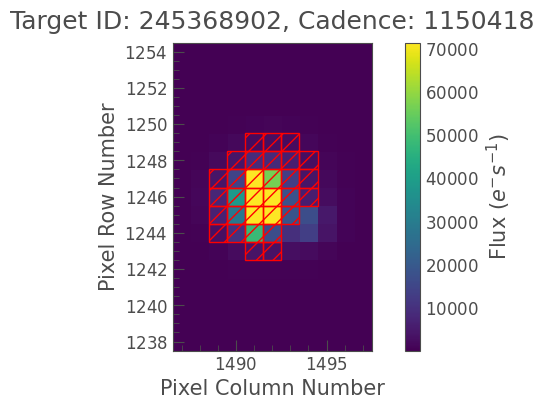

In [ ]:
tes.plot(aperture_mask=tes.pipeline_mask)

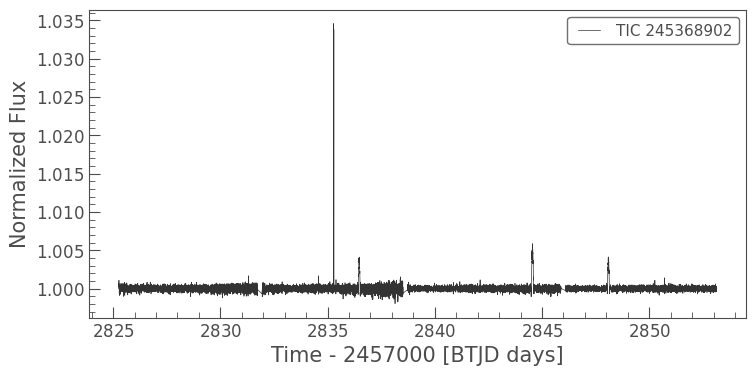

In [ ]:
lc = tes.to_lightcurve()
lc.flatten().plot(c='k', alpha=.8);

In [ ]:
# Apply pls method and remove outliers
lc = tes.to_lightcurve(method="pld").remove_outliers().flatten()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

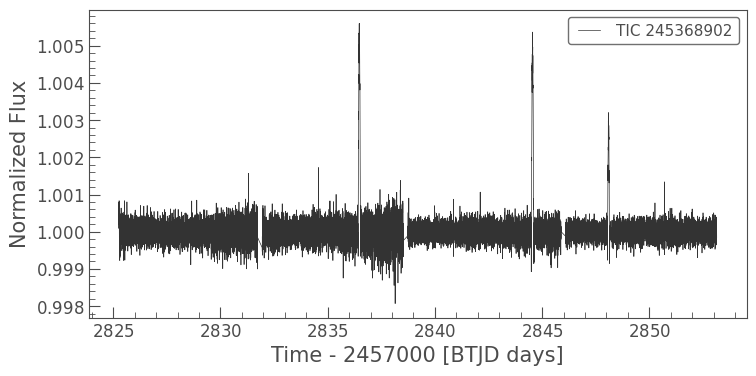

In [ ]:
lc.flatten().plot(c='k', alpha=.8)

In [ ]:
# Define period
period = lc.to_periodogram("bls").period_at_max_power
period

<Quantity 0.35130812 d>

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

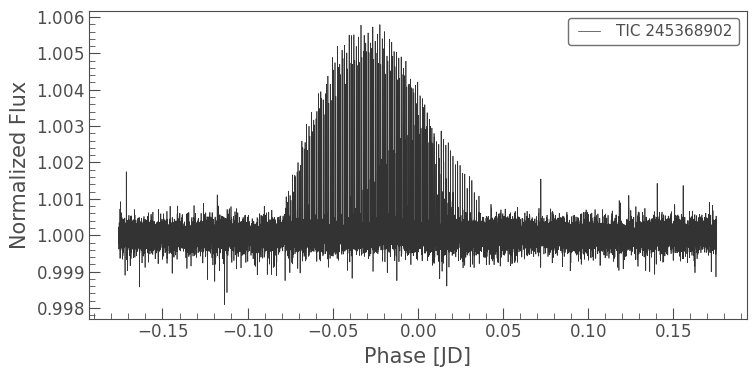

In [ ]:
lc.fold(period).plot() #.truncate(-0.5, -0.25).plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

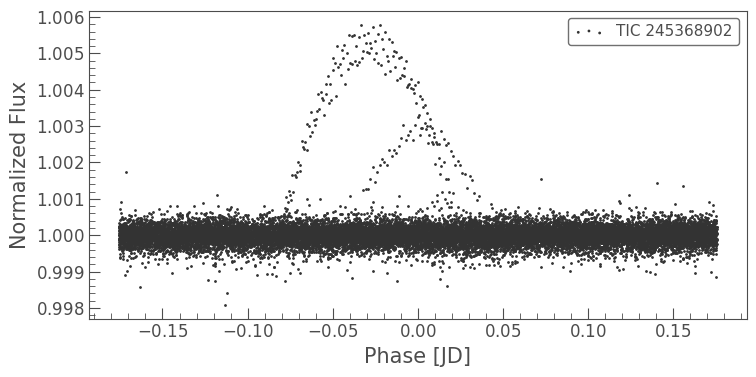

In [ ]:
lc.fold(period).scatter() #truncate(-0.5, -0.25).scatter()

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

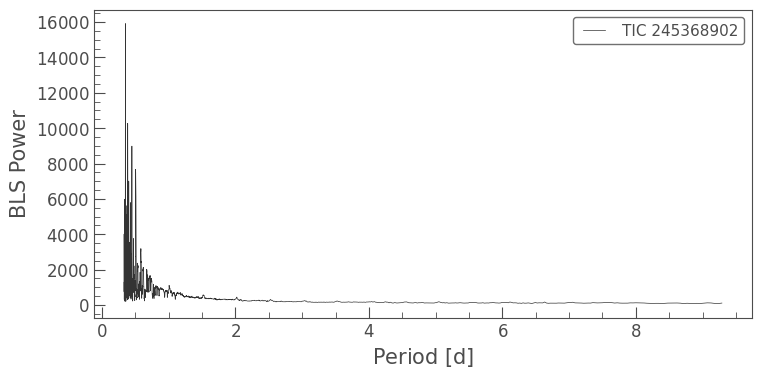

In [ ]:
lc.to_periodogram("bls").plot()